(np.float64(-0.5), np.float64(499.5), np.float64(332.5), np.float64(-0.5))

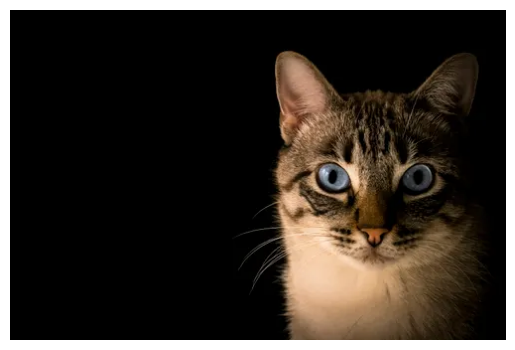

In [1]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

img = Image.open('/content/cat.webp')
img = img.convert('RGB')
plt.imshow(img)
plt.axis('off')

In [3]:
X_img = np.array(img)
X_img.shape

(333, 500, 3)

In [4]:
X_img = X_img.reshape(-1, 3)
X_img.shape

(166500, 3)

In [5]:
# Step 1
def find_closest_centroids(X, centroids):
  m, n = X.shape
  K = centroids.shape[0]

  idx = np.zeros((m, 1))

  for i in range(m):
    point = X[i]
    min_dist = 1e9
    closest_centroid = -1
    for j in range(K):
      centroid = centroids[j]
      sq_dist = np.sum((point - centroid) ** 2)

      if sq_dist < min_dist:
        min_dist = sq_dist
        closest_centroid = j
    idx[i] = closest_centroid

  return idx

In [47]:
# Step 2
def compute_centroids(X, idx, K):
  m, n = X.shape
  centroids = np.zeros((K, n))

  for i in range(K):
    indices = np.where(idx == i)[0]

    if len(indices):
      centroids[i] = np.mean(X[indices], axis=0)
    else:
      centroids[i] = Kmeans_init_centroids(X, 1)

  return centroids

In [48]:
def Kmeans_init_centroids(X, K):
  randidx = np.random.permutation(X.shape[0])
  centroids = X[randidx[:K]]

  return centroids

In [49]:
def run_Kmeans(X, initial_centroids, max_iters):
  m, n = X.shape
  K = initial_centroids.shape[0]

  centroids = initial_centroids

  idx = np.zeros(m)

  for i in range(max_iters):
    print("K-Means iteration %d/%d" % (i, max_iters-1))

    idx = find_closest_centroids(X, centroids)
    centroids = compute_centroids(X, idx, K)

  return centroids, idx

In [51]:
K = 12 # compress into 12 colors
max_iters = 10

initial_centroids = Kmeans_init_centroids(X_img, K)

centroids, idx = run_Kmeans(X_img, initial_centroids, max_iters)

K-Means iteration 0/9
K-Means iteration 1/9
K-Means iteration 2/9
K-Means iteration 3/9
K-Means iteration 4/9
K-Means iteration 5/9
K-Means iteration 6/9
K-Means iteration 7/9
K-Means iteration 8/9
K-Means iteration 9/9


In [52]:
valid_mask = ~np.isnan(centroids).any(axis=1)
valid_centroids = centroids[valid_mask]
valid_centroids

array([[2.87303013e+01, 1.85133820e+01, 6.33314617e+00],
       [9.88159363e+01, 6.85824701e+01, 3.67685259e+01],
       [2.34587372e+02, 1.93859694e+02, 1.56536033e+02],
       [1.25806227e+01, 5.92642199e+00, 1.49225952e+00],
       [1.55174814e-01, 7.27362907e-02, 3.65726319e-02],
       [6.56697833e+01, 4.87541436e+01, 2.77535062e+01],
       [1.44389324e+02, 1.09704087e+02, 7.80940784e+01],
       [4.58762729e+01, 3.29726748e+01, 1.65833333e+01],
       [1.84673012e+02, 1.43841587e+02, 1.08864978e+02],
       [1.16457286e+02, 1.21899497e+02, 1.29168342e+02],
       [8.01372064e+01, 6.47558714e+01, 4.61424598e+01],
       [1.14403562e+02, 8.66506252e+01, 5.88719212e+01]])

In [56]:
idx = idx.flatten()
idx = idx.astype(int)
X_img_compressed = valid_centroids[idx]

In [57]:
X_img_compressed = X_img_compressed.reshape((333, 500, 3))

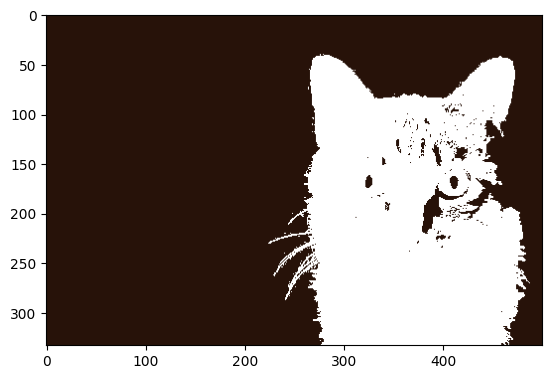

In [58]:
plt.imshow(X_img_compressed)